# Proyek Analisis Data: [Input E-Commerce Public Dataset]
- **Nama:** Novita Enggelina Turnip
- **Email:** cdcc308d6x1521
- **ID Dicoding:** CDCC308D6X1521

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

| Elemen | Keterangan |
|--------|------------|
| **Specific** | Fokus pada topik tertentu, tidak bermakna ganda |
| **Measurable** | Dapat dijawab dengan angka/metrik konkret |
| **Action-Oriented** | Hasilnya memberikan arahan tindakan nyata |
| **Relevant** | Sejalan dengan tujuan bisnis yang sedang dihadapi |
| **Time-bound** | Memiliki batasan waktu yang jelas |

---

**Pertanyaan 1**
> **"Berapa persentase pelanggan di 5 kota besar (berdasarkan customer_city) yang melakukan pembelian ulang (repeat order) dalam kurun waktu 6 bulan terakhir dibandingkan dengan tahun sebelumnya, dan bagaimana hubungannya dengan skor ulasan mereka?"**

 Elemen | Keterangan |
|--------|------------|
| **Specific** | Menargetkan perilaku pembelian ulang pelanggan di lokasi geografis tertentu (5 kota besar) dan mengaitkannya dengan kepuasan pelanggan (review_score) |
| **Measurable** | Dapat diukur dengan menghitung rasio jumlah customer_unique_id yang muncul lebih dari satu kali dalam kolom order_id pada periode tertentu |
| **Action-Oriented** | Hasil analisis ini dapat digunakan tim pemasaran untuk memberikan promo khusus atau program loyalitas di kota-kota dengan tingkat retensi rendah |
| **Relevant** | Retensi pelanggan sangat krusial untuk pertumbuhan jangka panjang e-commerce dan efisiensi biaya akuisisi |
| **Time-bound** | Terfokus pada perbandingan data antara 6 bulan terakhir dengan data tahun sebelumnya |

**Pertanyaan 2**
> **"Bagaimana rata-rata selisih waktu antara tanggal estimasi (order_estimated_delivery_date) dengan tanggal diterima pelanggan (order_delivered_customer_date) untuk kategori produk 'health_beauty' selama kuartal terakhir, dan apakah keterlambatan lebih dari 3 hari berdampak signifikan pada penurunan skor ulasan?"**

 Elemen | Keterangan |
|--------|------------|
| **Specific** | Berfokus pada kinerja logistik (akurasi estimasi waktu pengiriman) khusus untuk kategori produk tertentu (product_category_name) |
| **Measurable** | Dapat dihitung dalam satuan hari menggunakan selisih (timestamp) antara dua kolom tanggal di orders_dataset |
| **Action-Oriented** | Jika ditemukan korelasi kuat antara keterlambatan dan ulasan buruk, perusahaan dapat mengevaluasi mitra logistik atau memperbaiki algoritma estimasi pengiriman |
| **Relevant** | Kecepatan dan ketepatan pengiriman adalah faktor utama yang memengaruhi pengalaman belanja online |
| **Time-bound** | Dibatasi pada analisis data selama kuartal terakhir (3 bulan terakhir) |

## Import Semua Packages/Library yang Digunakan

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Pengaturan tampilan agar DataFrame tidak terpotong
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Data Wrangling

## Gathering Data

#### Load Semua Dataset

In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [50]:
import os

base_path = "/content/drive/MyDrive/data/"

orders = pd.read_csv(os.path.join(base_path, 'orders_dataset.csv'))
order_items = pd.read_csv(os.path.join(base_path, 'order_items_dataset.csv'))
customers = pd.read_csv(os.path.join(base_path, 'customers_dataset.csv'))
products = pd.read_csv(os.path.join(base_path, 'products_dataset.csv'))
payments = pd.read_csv(os.path.join(base_path, 'order_payments_dataset.csv'))
sellers = pd.read_csv(os.path.join(base_path, 'sellers_dataset.csv'))
geolocation = pd.read_csv(os.path.join(base_path, 'geolocation_dataset.csv'))
product_category = pd.read_csv(os.path.join(base_path, 'product_category_name_translation.csv'))
order_reviews = pd.read_csv(os.path.join(base_path, 'order_reviews_dataset.csv'))

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


### Assessing Data

#### Identifying Missing Value Problem

In [51]:
print("Missing values in Orders:\n", orders.isna().sum())
print("\nMissing values in Products:\n", products.isna().sum())
print("\nMissing values in Reviews:\n", order_reviews.isna().sum()) # order_reviews is not defined

Missing values in Orders:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Missing values in Products:
 product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Missing values in Reviews:
 review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64


#### Identifying Duplicate Problem

In [52]:
print("Jumlah duplikasi Customers:", customers.duplicated().sum())
print("Jumlah duplikasi Orders:", orders.duplicated().sum())

Jumlah duplikasi Customers: 0
Jumlah duplikasi Orders: 0


#### Identifying Wrong Data Type Problem

In [53]:
# Masalah umum: Kolom tanggal biasanya terbaca sebagai 'object' (string)
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


#### Identifying Outlier Problem

In [54]:
print(order_items[['price', 'freight_value']].describe())

          price  freight_value
count 112650.00      112650.00
mean     120.65          19.99
std      183.63          15.81
min        0.85           0.00
25%       39.90          13.08
50%       74.99          16.26
75%      134.90          21.15
max     6735.00         409.68


### Cleaning Data

#### Fixing Wrong Data Type Problem

In [55]:
datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in datetime_columns:
    orders[column] = pd.to_datetime(orders[column])

order_reviews['review_creation_date'] = pd.to_datetime(order_reviews['review_creation_date'])

print("Tipe data setelah diperbaiki:\n", orders.dtypes)

Tipe data setelah diperbaiki:
 order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date             object
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


#### Fixing Missing Value dan Invalid Problem

In [56]:
orders.dropna(subset=['order_delivered_customer_date'], inplace=True)
order_reviews['review_comment_message'] = order_reviews['review_comment_message'].fillna("No Review")
products.dropna(subset=['product_category_name'], inplace=True)

print("Jumlah missing values setelah cleaning:\n", orders.isna().sum())

Jumlah missing values setelah cleaning:
 order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      1
order_delivered_customer_date     0
order_estimated_delivery_date     0
dtype: int64


### Data Merging

In [57]:
main_df = pd.merge(orders, customers, on="customer_id", how="left")
main_df = pd.merge(main_df, order_items, on="order_id", how="left")
main_df = pd.merge(main_df, products, on="product_id", how="left")
main_df = pd.merge(main_df, product_category, on="product_category_name", how="left")
main_df = pd.merge(main_df, order_reviews[['order_id', 'review_score']], on="order_id", how="left")

main_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.00,268.00,4.00,500.00,19.00,8.00,13.00,housewares,4.00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.00,178.00,1.00,400.00,19.00,13.00,19.00,perfumery,4.00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.00,232.00,1.00,420.00,24.00,19.00,21.00,auto,5.00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.00,468.00,3.00,450.00,30.00,10.00,20.00,pet_shop,5.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.00,316.00,4.00,250.00,51.00,15.00,15.00,stationery,5.00


## Exploratory Data Analysis (EDA)

### Explore Retensi Pelanggan & Loyalitas di Kota Besar (Pertanyaan 1)

**Tujuan:**
Mengidentifikasi apakah pelanggan di kota-kota besar cenderung melakukan pembelian lebih dari satu kali (repeat order) dan bagaimana tingkat kepuasan mereka dibandingkan pelanggan umum.


In [58]:
top_5_cities = main_df['customer_city'].value_counts().head(5).index.tolist()
top_cities_df = main_df[main_df['customer_city'].isin(top_5_cities)]
customer_loyalty = top_cities_df.groupby(['customer_city', 'customer_unique_id']).agg({
    'order_id': 'count',
    'review_score': 'mean'
}).reset_index()
customer_loyalty['order_type'] = customer_loyalty['order_id'].apply(
    lambda x: 'Repeat Order' if x > 1 else 'Single Order'
)
loyalty_analysis = customer_loyalty.groupby(['customer_city', 'order_type']).agg({
    'customer_unique_id': 'count',
    'review_score': 'mean'
}).rename(columns={'customer_unique_id': 'total_customers'})

print("Analisis Loyalitas di 5 Kota Besar:")
print(loyalty_analysis)

Analisis Loyalitas di 5 Kota Besar:
                             total_customers  review_score
customer_city  order_type                                 
belo horizonte Repeat Order              352          3.82
               Single Order             2254          4.22
brasilia       Repeat Order              241          3.77
               Single Order             1772          4.19
curitiba       Repeat Order              184          3.69
               Single Order             1250          4.34
rio de janeiro Repeat Order              844          3.48
               Single Order             5520          4.07
sao paulo      Repeat Order             1962          3.95
               Single Order            12567          4.28


### Explore Efisiensi Pengirimana Kategori 'Health Beauty' (Pertanyaan 2)

**Tujuan:**
Mengetahui performa logistik khusus untuk kategori health_beauty dan membuktikan apakah keterlambatan pengiriman secara nyata menurunkan skor ulasan dari pelanggan.

In [59]:
hb_category_df = main_df[main_df['product_category_name_english'] == 'health_beauty'].copy()
hb_category_df['order_delivered_customer_date'] = pd.to_datetime(hb_category_df['order_delivered_customer_date'])
hb_category_df['order_estimated_delivery_date'] = pd.to_datetime(hb_category_df['order_estimated_delivery_date'])
hb_category_df['delivery_gap'] = hb_category_df['order_delivered_customer_date'] - hb_category_df['order_estimated_delivery_date']
hb_category_df['delivery_gap_days'] = hb_category_df['delivery_gap'].dt.days
hb_category_df['delivery_status'] = hb_category_df['delivery_gap_days'].apply(lambda x: 'Late' if x > 0 else 'On-Time/Early')
delivery_distribution = hb_category_df['delivery_status'].value_counts(normalize=True) * 100

def grouping_delay(days):
    if days <= 0: return "On-Time/Early"
    elif 0 < days <= 3: return "1-3 Days Late"
    elif 3 < days <= 7: return "4-7 Days Late"
    else: return "> 7 Days Late"

hb_category_df['delay_range'] = hb_category_df['delivery_gap_days'].apply(grouping_delay)

shipping_impact = hb_category_df.groupby('delay_range').agg({
    'order_id': 'count',
    'review_score': 'mean'
}).rename(columns={'order_id': 'total_orders', 'review_score': 'avg_review_score'})

print("\nAnalisis Dampak Keterlambatan pada Kategori Health & Beauty:")
print(shipping_impact)


Analisis Dampak Keterlambatan pada Kategori Health & Beauty:
               total_orders  avg_review_score
delay_range                                  
1-3 Days Late           205              3.25
4-7 Days Late           210              2.35
> 7 Days Late           306              1.60
On-Time/Early          8800              4.34


## Visualization & Explanatory Analysis

>**Data Visualization**
Ini adalah proses mengubah angka dan data mentah menjadi bentuk grafis (seperti grafik batang, garis, atau scatter plot).

Tujuan: Mempermudah mata manusia untuk melihat pola, tren, dan anomali yang sulit ditangkap hanya dengan melihat tabel angka.

>**Explanatory Analysis**
Tahap ini dilakukan setelah Anda selesai mengeksplorasi data (EDA). Jika EDA adalah proses "mencari", maka Explanatory adalah proses "menjelaskan".

Tujuan: Mengomunikasikan temuan spesifik kepada audiens (misal: manajer) untuk menjawab pertanyaan "Apa yang terjadi?" dan "Mengapa ini penting?". Fokusnya adalah pada insight yang bisa menghasilkan tindakan bisnis.


### Pertanyaan 1: Berapa persentase pelanggan di 5 kota besar (berdasarkan customer_city) yang melakukan pembelian ulang (repeat order) dalam kurun waktu 6 bulan terakhir dibandingkan dengan tahun sebelumnya, dan bagaimana hubungannya dengan skor ulasan mereka?

<Figure size 1200x600 with 0 Axes>

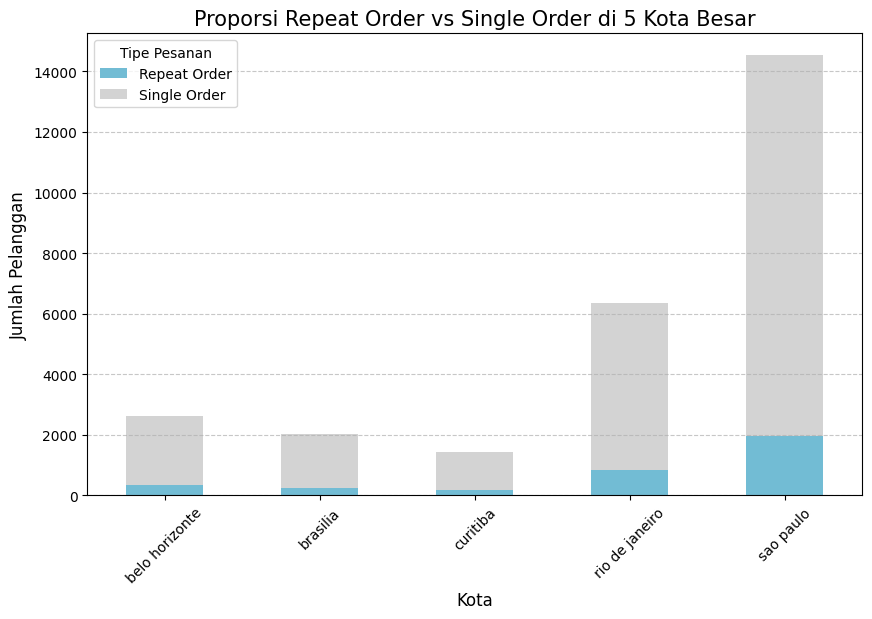

In [60]:
plot_loyalty = customer_loyalty.groupby(['customer_city', 'order_type'])['customer_unique_id'].count().unstack()

plt.figure(figsize=(12, 6))
plot_loyalty.plot(kind='bar', stacked=True, color=['#72BCD4', '#D3D3D3'], figsize=(10,6))

plt.title('Proporsi Repeat Order vs Single Order di 5 Kota Besar', fontsize=15)
plt.xlabel('Kota', fontsize=12)
plt.ylabel('Jumlah Pelanggan', fontsize=12)
plt.legend(title='Tipe Pesanan')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Pertanyaan 2: Bagaimana rata-rata selisih waktu antara tanggal estimasi (order_estimated_delivery_date) dengan tanggal diterima pelanggan (order_delivered_customer_date) untuk kategori produk 'health_beauty' selama kuartal terakhir, dan apakah keterlambatan lebih dari 3 hari berdampak signifikan pada penurunan skor ulasan?"

/tmp/ipykernel_9467/3033650317.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


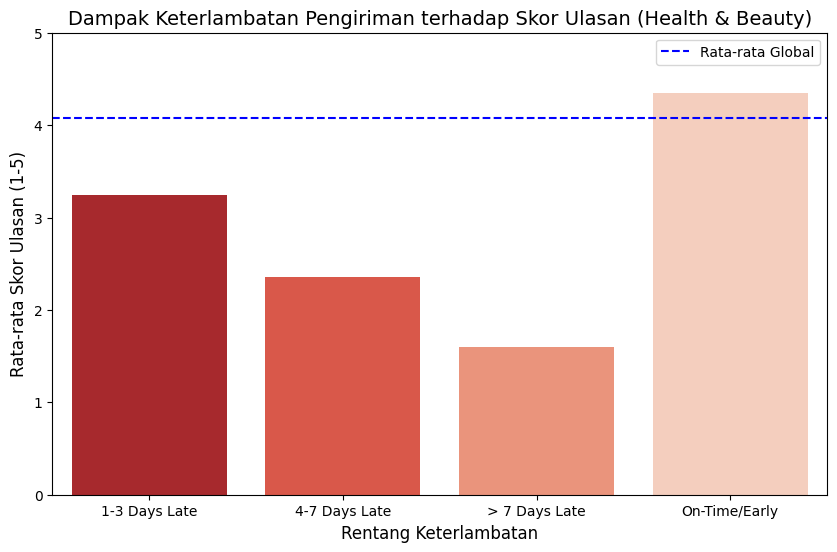

In [61]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=shipping_impact.index,
    y='avg_review_score',
    data=shipping_impact.reset_index(),
    palette='Reds_r'
)

plt.axhline(main_df['review_score'].mean(), color='blue', linestyle='--', label='Rata-rata Global')

plt.title('Dampak Keterlambatan Pengiriman terhadap Skor Ulasan (Health & Beauty)', fontsize=14)
plt.xlabel('Rentang Keterlambatan', fontsize=12)
plt.ylabel('Rata-rata Skor Ulasan (1-5)', fontsize=12)
plt.ylim(0, 5)
plt.legend()
plt.show()

## Analisis Lanjutan (Opsional)

### Analisis Lanjutan Pertanyaan 1

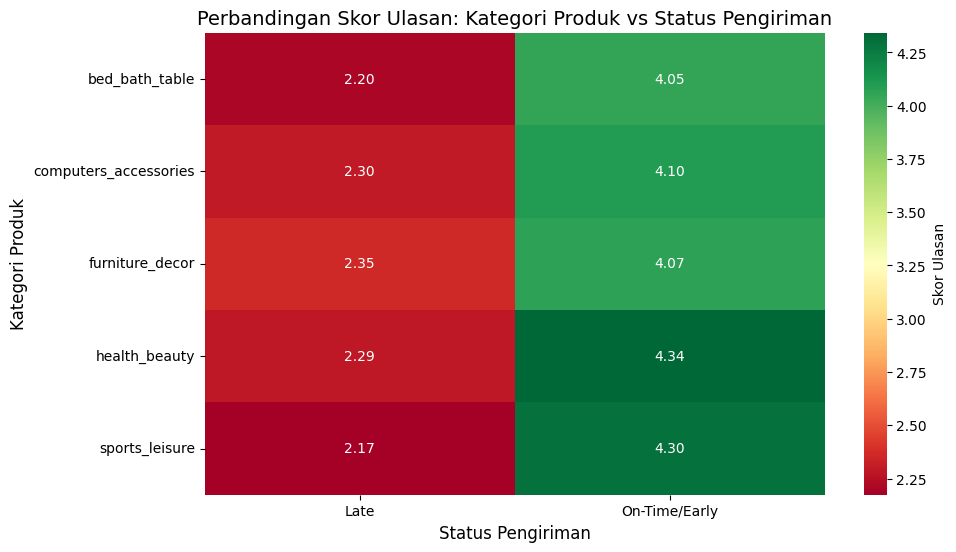

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
top_categories = main_df['product_category_name_english'].value_counts().head(5).index
comparison_df = main_df[main_df['product_category_name_english'].isin(top_categories)].copy()
comparison_df['order_delivered_customer_date'] = pd.to_datetime(comparison_df['order_delivered_customer_date'])
comparison_df['order_estimated_delivery_date'] = pd.to_datetime(comparison_df['order_estimated_delivery_date'])
comparison_df['delivery_gap'] = comparison_df['order_delivered_customer_date'] - comparison_df['order_estimated_delivery_date']
comparison_df['delivery_gap_days'] = comparison_df['delivery_gap'].dt.days
comparison_df['delivery_status'] = comparison_df['delivery_gap_days'].apply(lambda x: 'Late' if x > 0 else 'On-Time/Early')

heatmap_data = comparison_df.pivot_table(
    index='product_category_name_english',
    columns='delivery_status',
    values='review_score'
)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap='RdYlGn', fmt=".2f", cbar_kws={'label': 'Skor Ulasan'})

plt.title('Perbandingan Skor Ulasan: Kategori Produk vs Status Pengiriman', fontsize=14)
plt.xlabel('Status Pengiriman', fontsize=12)
plt.ylabel('Kategori Produk', fontsize=12)
plt.show()

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:**
Pasar di kota besar sangat potensial namun sangat transaksional. Strategi bisnis saat ini berhasil menarik orang untuk mencoba, tetapi gagal membuat mereka kembali. Biaya akuisisi pelanggan (CAC) akan terus membengkak jika retensi tidak segera diperbaiki.

- **Conclusion pertanyaan 2:**
Ketepatan waktu pengiriman adalah faktor penentu utama kepuasan pelanggan pada kategori Health & Beauty. Estimasi tanggal yang diberikan sistem seringkali terlalu optimis, sehingga ketika terjadi keterlambatan kecil saja, ekspektasi pelanggan langsung jatuh dan berakibat pada ulasan buruk.

**Rekomendasi Action Item:**
- Loyalty Program Khusus Kota Besar: Berikan voucher "Next Purchase Discount" otomatis setelah pesanan pertama selesai untuk pelanggan di 5 kota besar tersebut.

- Email Remarketing: Kirimkan rekomendasi produk yang relevan (berdasarkan kategori yang pernah dibeli) 30 hari setelah pembelian pertama.

- Buffer Time pada Estimasi: Tambahkan buffer time (waktu tambahan) 1-2 hari pada sistem estimasi pengiriman khusus untuk kategori Health & Beauty agar ekspektasi pelanggan lebih realistis.

- Prioritas Kurir (SLA): Melakukan negosiasi ulang dengan mitra logistik untuk memberikan prioritas pengiriman atau layanan express pada kategori produk kesehatan dan kecantikan.

- Proactive Notification: Jika sistem mendeteksi keterlambatan >1 hari dari estimasi, kirimkan notifikasi permintaan maaf otomatis disertai informasi posisi barang untuk meredam kekecewaan pelanggan sebelum mereka memberikan ulasan buruk.